# Chess Winner Predictor

Predicting who wins a chess game: white, black, or draw.

We build this one step at a time. Each step is one idea.

---

## Step 0 — get the data

This notebook needs `data/games.csv`.

Download it from the Kaggle dataset `datasnaek/chess`, from the **Data** tab
(not the Code tab), and put it in the `data/` folder.

Nothing below will run until that file is there.

---

## Step 1 — load the data and look at it

A **DataFrame** is a table in code: named columns, numbered rows.

We check three things straight away:

- `.shape` — rows and columns, to confirm it loaded properly
- `.head()` — the first 5 rows, so we see real values
- `.dtypes` — what kind of value each column holds (number / text / true-false)

In [1]:
import pandas as pd  # pandas is the library for working with tables

# Read the CSV file into a DataFrame (a table we can work with in code)
games = pd.read_csv("data/games.csv")

# .shape gives (number of rows, number of columns)
print("rows and columns:", games.shape)

# .head() shows the first 5 rows so we can see real values
games.head()

rows and columns: (20058, 16)


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [2]:
# .dtypes tells us what KIND of value sits in each column.
# object = text, int64 = whole number, float64 = decimal, bool = True/False
games.dtypes

id                    str
rated                bool
created_at        float64
last_move_at      float64
turns               int64
victory_status        str
winner                str
increment_code        str
white_id              str
white_rating        int64
black_id              str
black_rating        int64
moves                 str
opening_eco           str
opening_name          str
opening_ply         int64
dtype: object

### Are any values missing?

Real datasets usually have holes — a blank rating, an empty name.
Missing values break most models, so we check before trusting anything.

`.isna()` marks every cell as True (missing) or False (present).
`.sum()` then counts the Trues, column by column.

In [3]:
# .isna() flags each cell as missing (True) or present (False)
# .sum() counts the True values for each column
missing = games.isna().sum()

# Show the total across the whole table, then the per-column breakdown
print("total missing values in the entire dataset:", missing.sum())
print()
missing

total missing values in the entire dataset: 0



id                0
rated             0
created_at        0
last_move_at      0
turns             0
victory_status    0
winner            0
increment_code    0
white_id          0
white_rating      0
black_id          0
black_rating      0
moves             0
opening_eco       0
opening_name      0
opening_ply       0
dtype: int64

---

## Step 2 — look at the label

The **label** is what we are trying to predict: the `winner` column.

Before predicting something, find out how often each answer happens.
If one answer dominates, a model can score well by always guessing it
while having learned nothing.

In [4]:
# value_counts() counts how many times each value appears in a column
counts = games["winner"].value_counts()

# normalize=True gives the share (0 to 1) instead of the raw count
shares = games["winner"].value_counts(normalize=True)

# Put them side by side in one small table, as percentages
summary = pd.DataFrame({"games": counts, "percent": (shares * 100).round(1)})
summary

,games,percent
winner,,
white,10001,49.9
black,9107,45.4
draw,950,4.7


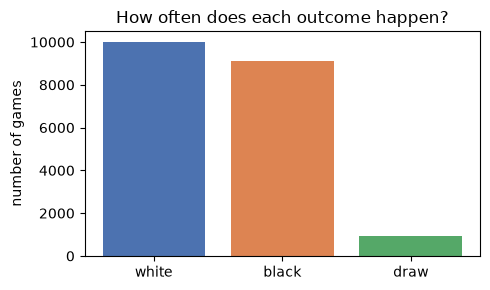

In [5]:
import matplotlib.pyplot as plt  # the standard plotting library

fig, ax = plt.subplots(figsize=(5, 3))

# One bar per outcome, so the imbalance is obvious at a glance
ax.bar(counts.index, counts.values, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylabel("number of games")
ax.set_title("How often does each outcome happen?")

plt.tight_layout()
plt.show()

---

## Step 3 — three charts

Looking for patterns in the things we are *allowed* to use.

Colours are fixed per outcome everywhere: white = blue, black = orange, draw = green.

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Fixed colour per outcome, used identically in all three charts
C = {"white": "#2a78d6", "black": "#eb6834", "draw": "#1baf7a"}
INK, MUTED = "#0b0b0b", "#52514e"

def tidy(ax):
    """Push the frame and grid into the background so the data reads first."""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color("#d4d3cd")
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.grid(axis="y", color="#e8e7e2", lw=0.8)
    ax.set_axisbelow(True)   # grid behind the bars, never on top

### 1. Rating difference vs who wins

`rating_diff` = white rating − black rating. Positive means white is stronger.
We bucket games by that gap, then ask what share of each bucket each outcome won.

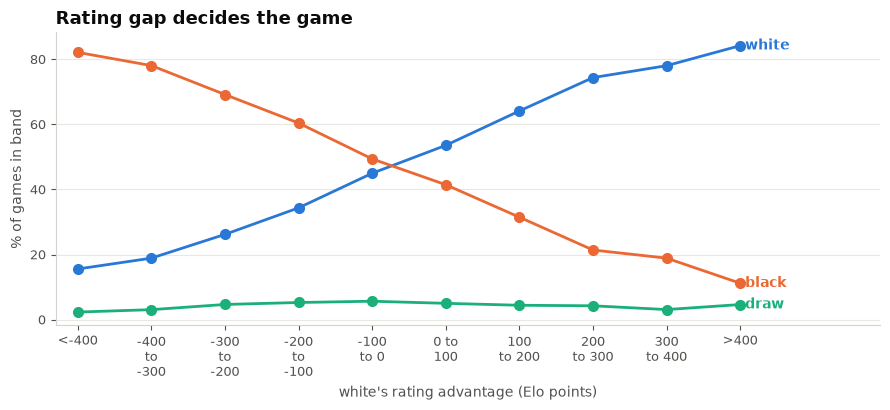

winner          black  draw  white
diff_band                         
<-400            82.1   2.3   15.6
-400\nto\n-300   78.1   3.1   18.9
-300\nto\n-200   69.2   4.7   26.2
-200\nto\n-100   60.4   5.3   34.3
-100\nto 0       49.4   5.7   45.0
0 to\n100        41.5   5.0   53.5
100\nto 200      31.5   4.4   64.1
200\nto 300      21.4   4.2   74.4
300\nto 400      18.9   3.1   78.0
>400             11.2   4.6   84.2


In [7]:
# How much stronger is white? Negative = black is stronger.
games["rating_diff"] = games["white_rating"] - games["black_rating"]

# Group the gap into readable bands rather than plotting 20,058 individual points
bins   = [-3000, -400, -300, -200, -100, 0, 100, 200, 300, 400, 3000]
labels = ["<-400","-400\nto\n-300","-300\nto\n-200","-200\nto\n-100","-100\nto 0",
          "0 to\n100","100\nto 200","200\nto 300","300\nto 400",">400"]
games["diff_band"] = pd.cut(games["rating_diff"], bins=bins, labels=labels)

# For each band, what share of games did each outcome take?
by_band = pd.crosstab(games["diff_band"], games["winner"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(by_band))
for outcome in ["white", "black", "draw"]:
    ax.plot(x, by_band[outcome], marker="o", ms=7, lw=2,
            color=C[outcome], label=outcome)
    # Direct label at the right end, so colour is never the only cue
    ax.annotate(f" {outcome}", (x[-1], by_band[outcome].iloc[-1]),
                color=C[outcome], fontsize=10, va="center", fontweight="bold")

ax.set_xticks(x, by_band.index, fontsize=8)
ax.set_xlabel("white's rating advantage (Elo points)", color=MUTED, fontsize=10)
ax.set_ylabel("% of games in band", color=MUTED, fontsize=10)
ax.set_title("Rating gap decides the game", color=INK, fontsize=13, fontweight="bold", loc="left")
ax.set_xlim(-0.3, len(x) + 0.9)
tidy(ax)
plt.tight_layout(); plt.show()

print(by_band.round(1))

### 2. Win rates by time control

`increment_code` looks like `"15+2"` = 15 minutes each, +2 seconds per move.
It is text, so we split it apart and group into the usual chess speed categories.

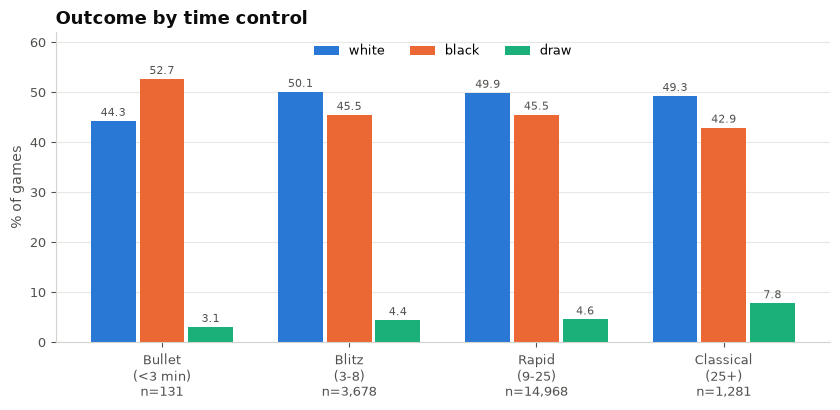

In [8]:
# "15+2" -> base 15, increment 2. expand=True puts each part in its own column.
tc = games["increment_code"].str.split("+", n=1, expand=True)
games["base_min"] = pd.to_numeric(tc[0], errors="coerce")

# Standard chess speed bands, by base minutes on the clock
speed_bins   = [-1, 2, 8, 25, 10_000]
speed_labels = ["Bullet\n(<3 min)", "Blitz\n(3-8)", "Rapid\n(9-25)", "Classical\n(25+)"]
games["speed"] = pd.cut(games["base_min"], bins=speed_bins, labels=speed_labels)

by_speed = pd.crosstab(games["speed"], games["winner"], normalize="index") * 100
n_speed  = games["speed"].value_counts().reindex(by_speed.index)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
x, w = np.arange(len(by_speed)), 0.26
for i, outcome in enumerate(["white", "black", "draw"]):
    pos = x + (i - 1) * w
    ax.bar(pos, by_speed[outcome], w * 0.92, color=C[outcome], label=outcome)
    # Value on every bar - required, since one of our colours is low-contrast
    for px, v in zip(pos, by_speed[outcome]):
        ax.text(px, v + 1, f"{v:.1f}", ha="center", fontsize=8, color=MUTED)

ax.set_xticks(x, [f"{lab}\nn={n:,}" for lab, n in zip(by_speed.index, n_speed)], fontsize=8)
ax.set_ylabel("% of games", color=MUTED, fontsize=10)
ax.set_title("Outcome by time control", color=INK, fontsize=13, fontweight="bold", loc="left")
ax.legend(frameon=False, fontsize=9, ncol=3, loc="upper center")
ax.set_ylim(0, 62)
tidy(ax)
plt.tight_layout(); plt.show()

### 3. The 10 most common openings, and how white does in each

Reminder: the opening is chosen *during* play, so this is a "grey zone" column.
We are looking, not training on it.

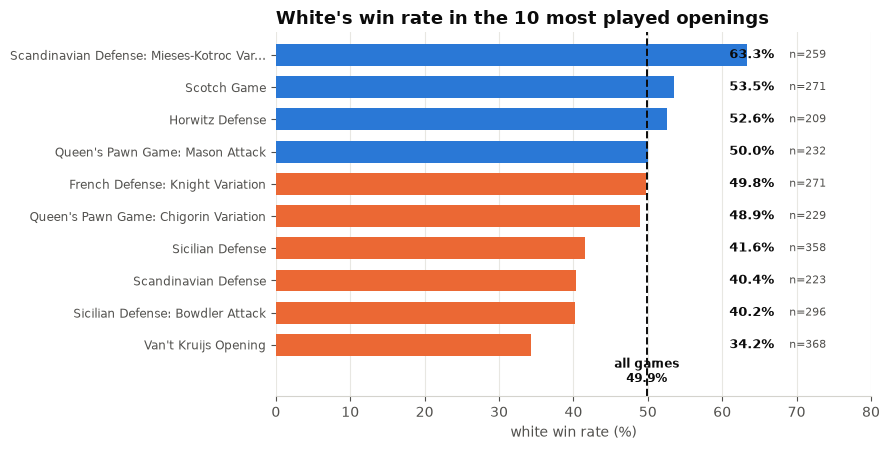

In [9]:
top10 = games["opening_name"].value_counts().head(10).index

sub = games[games["opening_name"].isin(top10)]
white_rate = (pd.crosstab(sub["opening_name"], sub["winner"], normalize="index")["white"] * 100)
counts10 = games["opening_name"].value_counts().head(10)
white_rate = white_rate.reindex(counts10.index).sort_values()

overall = (games["winner"] == "white").mean() * 100   # 49.9% -- the line to beat

fig, ax = plt.subplots(figsize=(9, 4.6))
colors = [C["white"] if v >= overall else C["black"] for v in white_rate]
ax.barh(range(len(white_rate)), white_rate.values, color=colors, height=0.68)

# Labels in a fixed column past every bar, so nothing collides with the line
for i, (name, v) in enumerate(white_rate.items()):
    ax.text(67, i, f"{v:.1f}%", va="center", ha="right",
            fontsize=9, color=INK, fontweight="bold")
    ax.text(69, i, f"n={counts10[name]:,}", va="center",
            fontsize=8, color=MUTED)

# The overall white win rate, so each bar is read as better or worse than average
ax.axvline(overall, color=INK, lw=1.4, ls="--")
ax.text(overall, -1.15, f"all games\n{overall:.1f}%", ha="center",
        fontsize=8.5, color=INK, fontweight="bold")

short = [n if len(n) <= 42 else n[:39] + "..." for n in white_rate.index]
ax.set_yticks(range(len(white_rate)), short, fontsize=8.5)
ax.set_xlabel("white win rate (%)", color=MUTED, fontsize=10)
ax.set_title("White's win rate in the 10 most played openings",
             color=INK, fontsize=13, fontweight="bold", loc="left")
ax.set_xlim(0, 80)
ax.grid(axis="x", color="#e8e7e2", lw=0.8); ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#d4d3cd"); ax.tick_params(colors=MUTED)
ax.set_ylim(-1.6, len(white_rate) - 0.3)
plt.tight_layout(); plt.show()

---

## Step 5 — build the features

A **feature** is one number the model gets to see.
A **feature matrix** is the table of them — every column a number,
every number knowable *before the first move*.

`rating_diff` is a **derived feature**: it was not in the file, we made it.

In [10]:
def build_features(df):
    """Pre-game features only. Takes the raw table, returns a table of numbers."""
    X = pd.DataFrame(index=df.index)   # empty table, same rows as the input

    # --- ratings: known before anyone moves ---
    X["white_rating"] = df["white_rating"]
    X["black_rating"] = df["black_rating"]
    X["rating_diff"]  = df["white_rating"] - df["black_rating"]   # the strongest signal
    X["rating_mean"]  = (df["white_rating"] + df["black_rating"]) / 2

    # --- was it a rated game? True/False -> 1/0, because models need numbers ---
    X["rated"] = df["rated"].astype(int)

    # --- time control: "15+2" is TEXT, so split it into two numbers ---
    tc = df["increment_code"].str.split("+", n=1, expand=True)
    X["base_min"]      = pd.to_numeric(tc[0], errors="coerce")  # minutes on the clock
    X["increment_sec"] = pd.to_numeric(tc[1], errors="coerce")  # seconds added per move

    return X


X = build_features(games)   # the feature matrix
y = games["winner"]         # the label -- what we are predicting

print("feature matrix:", X.shape)
print("label:", y.shape)
X.head()

feature matrix: (20058, 7)
label: (20058,)


,white_rating,black_rating,rating_diff,rating_mean,rated,base_min,increment_sec
0,1500,1191,309,1345.5,0,15,2
1,1322,1261,61,1291.5,1,5,10
2,1496,1500,-4,1498.0,1,5,10
3,1439,1454,-15,1446.5,1,20,0
4,1523,1469,54,1496.0,1,30,3


In [11]:
# Sanity check: has any banned column snuck in?
BANNED = ["victory_status", "turns", "moves", "last_move_at"]
leaked = [c for c in X.columns if c in BANNED]
print("banned columns in X:", leaked if leaked else "none - clean")

# Any missing values? Models cannot handle them.
print("missing values in X:", int(X.isna().sum().sum()))

banned columns in X: none - clean
missing values in X: 0


---

## Step 4 — split into train and test

The model learns from the **training set** and is judged on the **test set**,
which it never sees during training.

`stratify=y` keeps the same white/black/draw mix in both halves — important
because draws are only 4.7% of games.

In [12]:
from sklearn.model_selection import train_test_split

# Four things come back, always in this order
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                 # what to split
    test_size=0.2,        # hold back 20% for testing
    stratify=y,           # keep the white/black/draw mix identical in both halves
    random_state=42,      # same split every time we run this
)

print(f"train: {len(X_train):,} games   test: {len(X_test):,} games")
print()
print("label mix (%):")
print(pd.DataFrame({
    "train": (y_train.value_counts(normalize=True) * 100).round(2),
    "test":  (y_test.value_counts(normalize=True) * 100).round(2),
}))

train: 16,046 games   test: 4,012 games

label mix (%):
        train   test
winner              
white   49.86  49.85
black   45.40  45.41
draw     4.74   4.74


---

## Step 6 — how deep should the tree be?

A **decision tree** asks yes/no questions about the features.
`max_depth` caps how many questions deep it may go.

Too shallow → it cannot learn enough (**underfitting**).
Too deep → it memorises the training games (**overfitting**).

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [2, 4, 6, 8, 12, None]
rows = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)                    # learn from the training set only

    # Score on BOTH sets -- the gap between them is what reveals overfitting
    train_acc = accuracy_score(y_train, tree.predict(X_train))
    test_acc  = accuracy_score(y_test,  tree.predict(X_test))

    rows.append({"max_depth": "None" if d is None else d,
                 "train": train_acc, "test": test_acc,
                 "gap": train_acc - test_acc,
                 "leaves": tree.get_n_leaves()})

results = pd.DataFrame(rows)
print(results.round(4).to_string(index=False))

max_depth  train   test    gap  leaves
        2 0.6142 0.6109 0.0033       4
        4 0.6221 0.6191 0.0030      16
        6 0.6298 0.6147 0.0152      64
        8 0.6425 0.6117 0.0309     196
       12 0.6824 0.5990 0.0835     790
     None 0.9902 0.5738 0.4164    5364


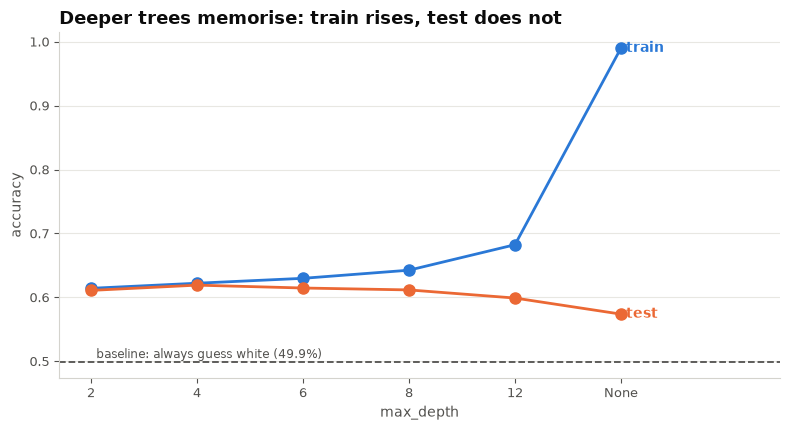

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.4))
x = np.arange(len(results))

ax.plot(x, results["train"], marker="o", ms=8, lw=2, color="#2a78d6")
ax.plot(x, results["test"],  marker="o", ms=8, lw=2, color="#eb6834")

# Direct labels, so colour is never the only way to tell the lines apart
ax.annotate(" train", (x[-1], results["train"].iloc[-1]), color="#2a78d6",
            fontweight="bold", va="center", fontsize=10)
ax.annotate(" test",  (x[-1], results["test"].iloc[-1]),  color="#eb6834",
            fontweight="bold", va="center", fontsize=10)

# The always-guess-white baseline: anything below this line is worthless
ax.axhline(0.4986, ls="--", lw=1.3, color="#52514e")
ax.text(0.05, 0.505, "baseline: always guess white (49.9%)", fontsize=8.5, color="#52514e")

ax.set_xticks(x, results["max_depth"])
ax.set_xlabel("max_depth", color="#52514e", fontsize=10)
ax.set_ylabel("accuracy", color="#52514e", fontsize=10)
ax.set_title("Deeper trees memorise: train rises, test does not",
             color="#0b0b0b", fontsize=13, fontweight="bold", loc="left")
ax.set_xlim(-0.3, len(x) + 0.5)
tidy(ax)
plt.tight_layout(); plt.show()

### A random forest, for comparison

A **random forest** is many decision trees, each trained on a random slice of
the data and a random subset of the features. They vote. Individual trees
overfit; their mistakes disagree, so averaging cancels much of it out.

In [15]:
from sklearn.ensemble import RandomForestClassifier

for md, label in [(None, "unlimited depth"), (8, "max_depth=8")]:
    rf = RandomForestClassifier(n_estimators=300, max_depth=md,
                                random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    tr = accuracy_score(y_train, rf.predict(X_train))
    te = accuracy_score(y_test,  rf.predict(X_test))
    print(f"{label:16s} train {tr:.4f}   test {te:.4f}   gap {tr-te:.4f}")

# Keep the tuned one -- best test score, small gap
best = RandomForestClassifier(n_estimators=300, max_depth=8,
                              random_state=42, n_jobs=-1).fit(X_train, y_train)

unlimited depth  train 0.9902   test 0.6251   gap 0.3650


max_depth=8      train 0.6577   test 0.6261   gap 0.0316


### Feature importance

**Feature importance** = how much each feature helped the model split the data.
It shows what the model leaned on. It does *not* prove causation.

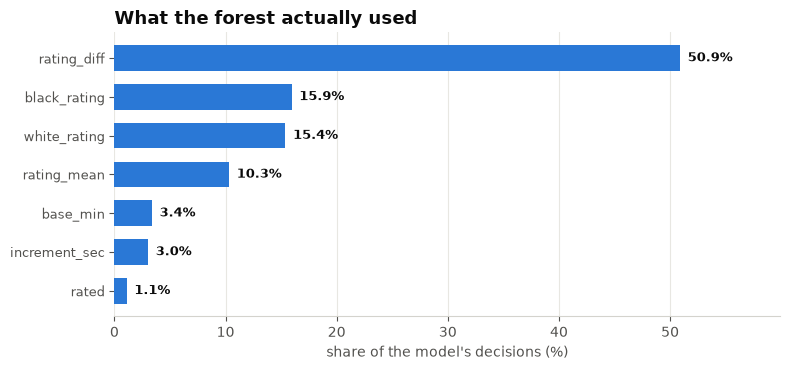

rating_diff      50.9
black_rating     15.9
white_rating     15.4
rating_mean      10.3
base_min          3.4
increment_sec     3.0
rated             1.1


In [16]:
imp = pd.Series(best.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(range(len(imp)), imp.values * 100, color="#2a78d6", height=0.66)

for i, v in enumerate(imp.values * 100):
    ax.text(v + 0.7, i, f"{v:.1f}%", va="center", fontsize=9,
            color="#0b0b0b", fontweight="bold")

ax.set_yticks(range(len(imp)), imp.index, fontsize=9.5)
ax.set_xlabel("share of the model's decisions (%)", color="#52514e", fontsize=10)
ax.set_title("What the forest actually used", color="#0b0b0b",
             fontsize=13, fontweight="bold", loc="left")
ax.set_xlim(0, max(imp.values * 100) + 9)
ax.grid(axis="x", color="#e8e7e2", lw=0.8); ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#d4d3cd"); ax.tick_params(colors="#52514e")
plt.tight_layout(); plt.show()

print((imp.sort_values(ascending=False) * 100).round(1).to_string())